/tmp/ipython-input-996263677.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_data, x='Country', y=col, palette='Set2')


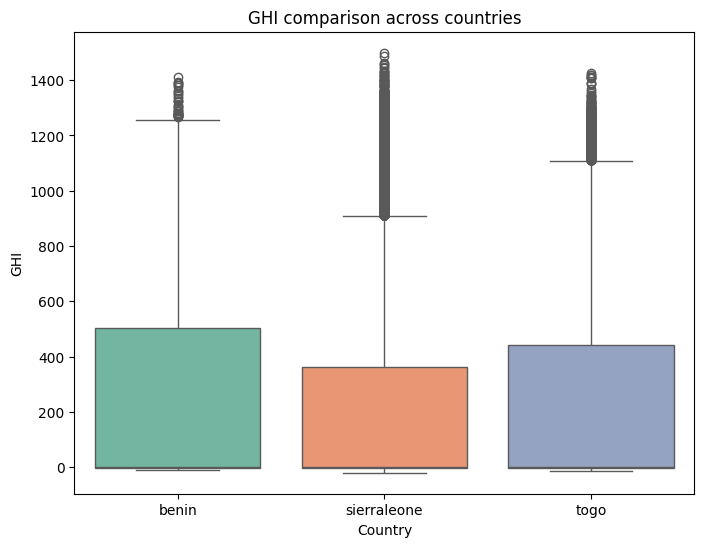

/tmp/ipython-input-996263677.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_data, x='Country', y=col, palette='Set2')


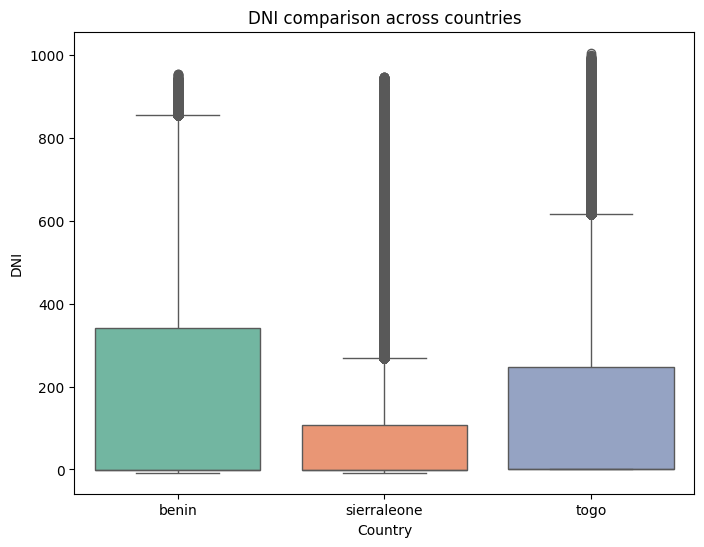

/tmp/ipython-input-996263677.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_data, x='Country', y=col, palette='Set2')


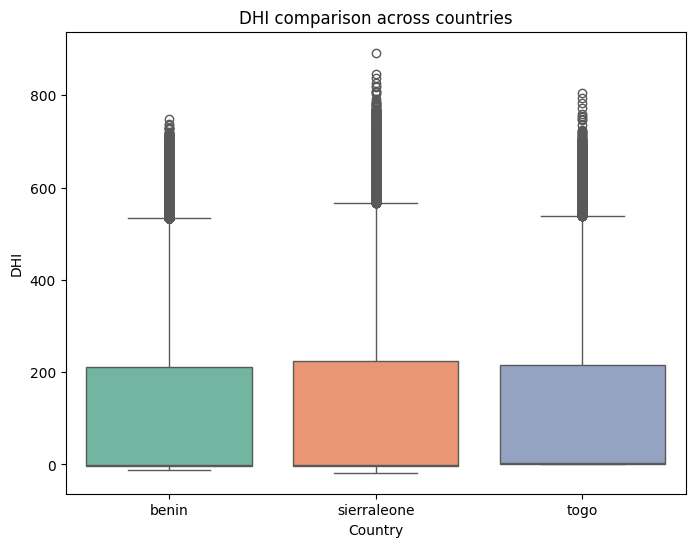

,Metric,GHI,DNI,DHI,Country
0,mean,243.791792,175.064008,113.734928,benin
1,median,0.000000,-0.200000,-0.100000,benin
2,std,334.456032,267.105369,158.365653,benin
3,mean,201.957515,116.376337,113.720571,sierraleone
4,median,0.300000,-0.100000,-0.100000,sierraleone
5,std,298.495150,218.652659,158.946032,sierraleone
6,mean,230.555040,151.258469,116.444352,togo
7,median,2.100000,0.000000,2.500000,togo
8,std,322.532347,250.956962,156.520714,togo


ANOVA for GHI: F=2201.12, p=0.0000
ANOVA for DNI: F=6958.66, p=0.0000
ANOVA for DHI: F=50.11, p=0.0000


/tmp/ipython-input-996263677.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ghi_means.index, y=ghi_means.values, palette='Set3')


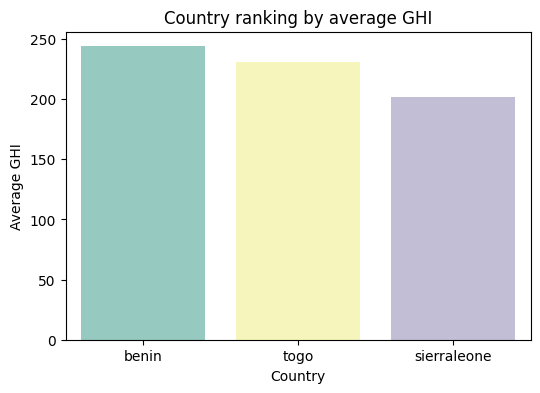

In [1]:
# compare_countries.py
# Template for cross-country solar dataset comparison

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -----------------------------
# Load cleaned datasets
# -----------------------------
countries = ['benin', 'sierraleone', 'togo']
cleaned_data = {}
for country in countries:
    path = f'/content/{country}_clean.csv'
    cleaned_data[country] = pd.read_csv(path, parse_dates=['Timestamp'])

# Concatenate for easier plotting
for country, df in cleaned_data.items():
    df['Country'] = country
all_data = pd.concat(cleaned_data.values(), ignore_index=True)

numeric_cols = ['GHI', 'DNI', 'DHI']

# -----------------------------
# Boxplots: side-by-side by country
# -----------------------------
for col in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=all_data, x='Country', y=col, palette='Set2')
    plt.title(f'{col} comparison across countries')
    plt.show()

# -----------------------------
# Summary Table: mean, median, std
# -----------------------------
summary_list = []
for country, df in cleaned_data.items():
    summary_list.append(df[numeric_cols].agg(['mean','median','std']).assign(Country=country))
summary_table = pd.concat(summary_list)
summary_table = summary_table.reset_index().rename(columns={'index':'Metric'})
display(summary_table)

# -----------------------------
# Statistical Testing (one-way ANOVA)
# -----------------------------
for col in numeric_cols:
    groups = [cleaned_data[country][col].dropna() for country in countries]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA for {col}: F={f_stat:.2f}, p={p_val:.4f}")

# Optional: if data not normal, use Kruskal-Wallis
# from scipy.stats import kruskal
# for col in numeric_cols:
#     groups = [cleaned_data[country][col].dropna() for country in countries]
#     stat, p_val = kruskal(*groups)
#     print(f"Kruskal-Wallis for {col}: stat={stat:.2f}, p={p_val:.4f}")

# -----------------------------
# Bonus: Ranking by average GHI
# -----------------------------
ghi_means = all_data.groupby('Country')['GHI'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=ghi_means.index, y=ghi_means.values, palette='Set3')
plt.ylabel('Average GHI')
plt.title('Country ranking by average GHI')
plt.show()

# -----------------------------
# Key Observations (to put in markdown)
# -----------------------------
# - Example: Benin shows the highest median GHI but also largest variability.
# - Sierra Leone has more consistent DNI values.
# - Togo shows moderate GHI and lower variability.
